## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [4]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [5]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [6]:
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB
None


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine predictors and target
data = pd.concat([X, y], axis=1)
print(data.head())

   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0


In [10]:
df=data.copy()

In [11]:
print(df.describe())

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

In [12]:
# Correlation matrix
cnum_df = df.select_dtypes(include=np.number).corr()
cnum_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
X,1.000000,0.539548,-0.021039,-0.048384,-0.085916,0.006210,-0.051258,0.085223,0.018798,0.065387,0.063385
Y,0.539548,1.000000,-0.046308,0.007782,-0.101178,-0.024488,-0.024103,0.062221,-0.020341,0.033234,0.044873
FFMC,-0.021039,-0.046308,1.000000,0.382619,0.330512,0.531805,0.431532,-0.300995,-0.028485,0.056702,0.040122
DMC,-0.048384,0.007782,0.382619,1.000000,0.682192,0.305128,0.469594,0.073795,-0.105342,0.074790,0.072994
DC,-0.085916,-0.101178,0.330512,0.682192,1.000000,0.229154,0.496208,-0.039192,-0.203466,0.035861,0.049383
ISI,0.006210,-0.024488,0.531805,0.305128,0.229154,1.000000,0.394287,-0.132517,0.106826,0.067668,0.008258
temp,-0.051258,-0.024103,0.431532,0.469594,0.496208,0.394287,1.000000,-0.527390,-0.227116,0.069491,0.097844
RH,0.085223,0.062221,-0.300995,0.073795,-0.039192,-0.132517,-0.527390,1.000000,0.069410,0.099751,-0.075519
wind,0.018798,-0.020341,-0.028485,-0.105342,-0.203466,0.106826,-0.227116,0.069410,1.000000,0.061119,0.012317
rain,0.065387,0.033234,0.056702,0.074790,0.035861,0.067668,0.069491,0.099751,0.061119,1.000000,-0.007366


In [13]:
r_value = df["rain"].corr(df['area'])
r_value

-0.007365729279292286

In [14]:
from scipy import stats

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

print(corr["area"].sort_values(ascending=False))

area    1.000000
temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64


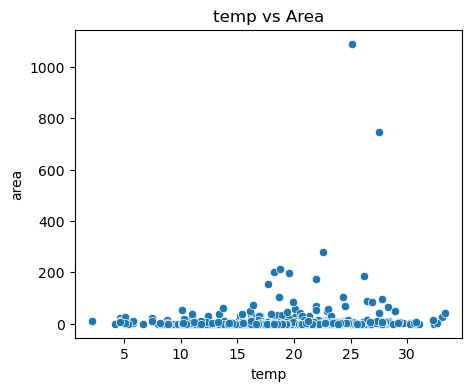

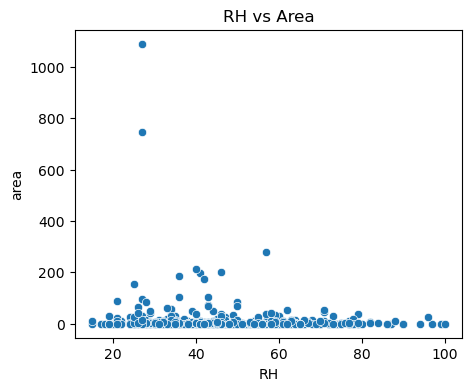

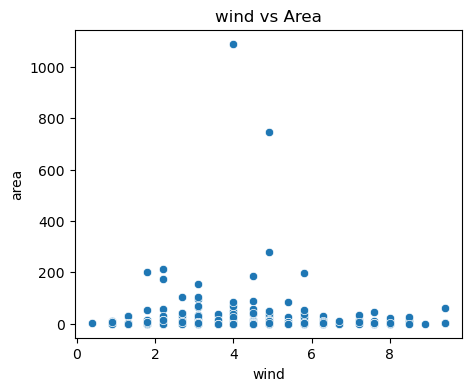

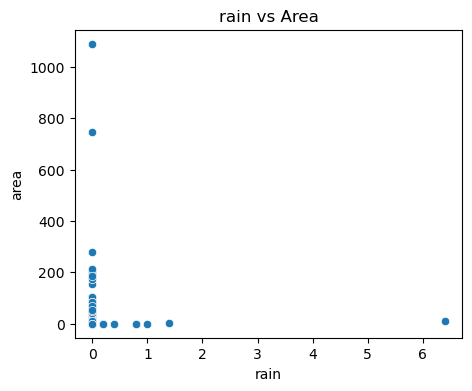

In [16]:
# Scatterplots
predictors = ["temp","RH","wind","rain"]

for col in predictors:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df["area"])
    plt.title(f"{col} vs Area")
    plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

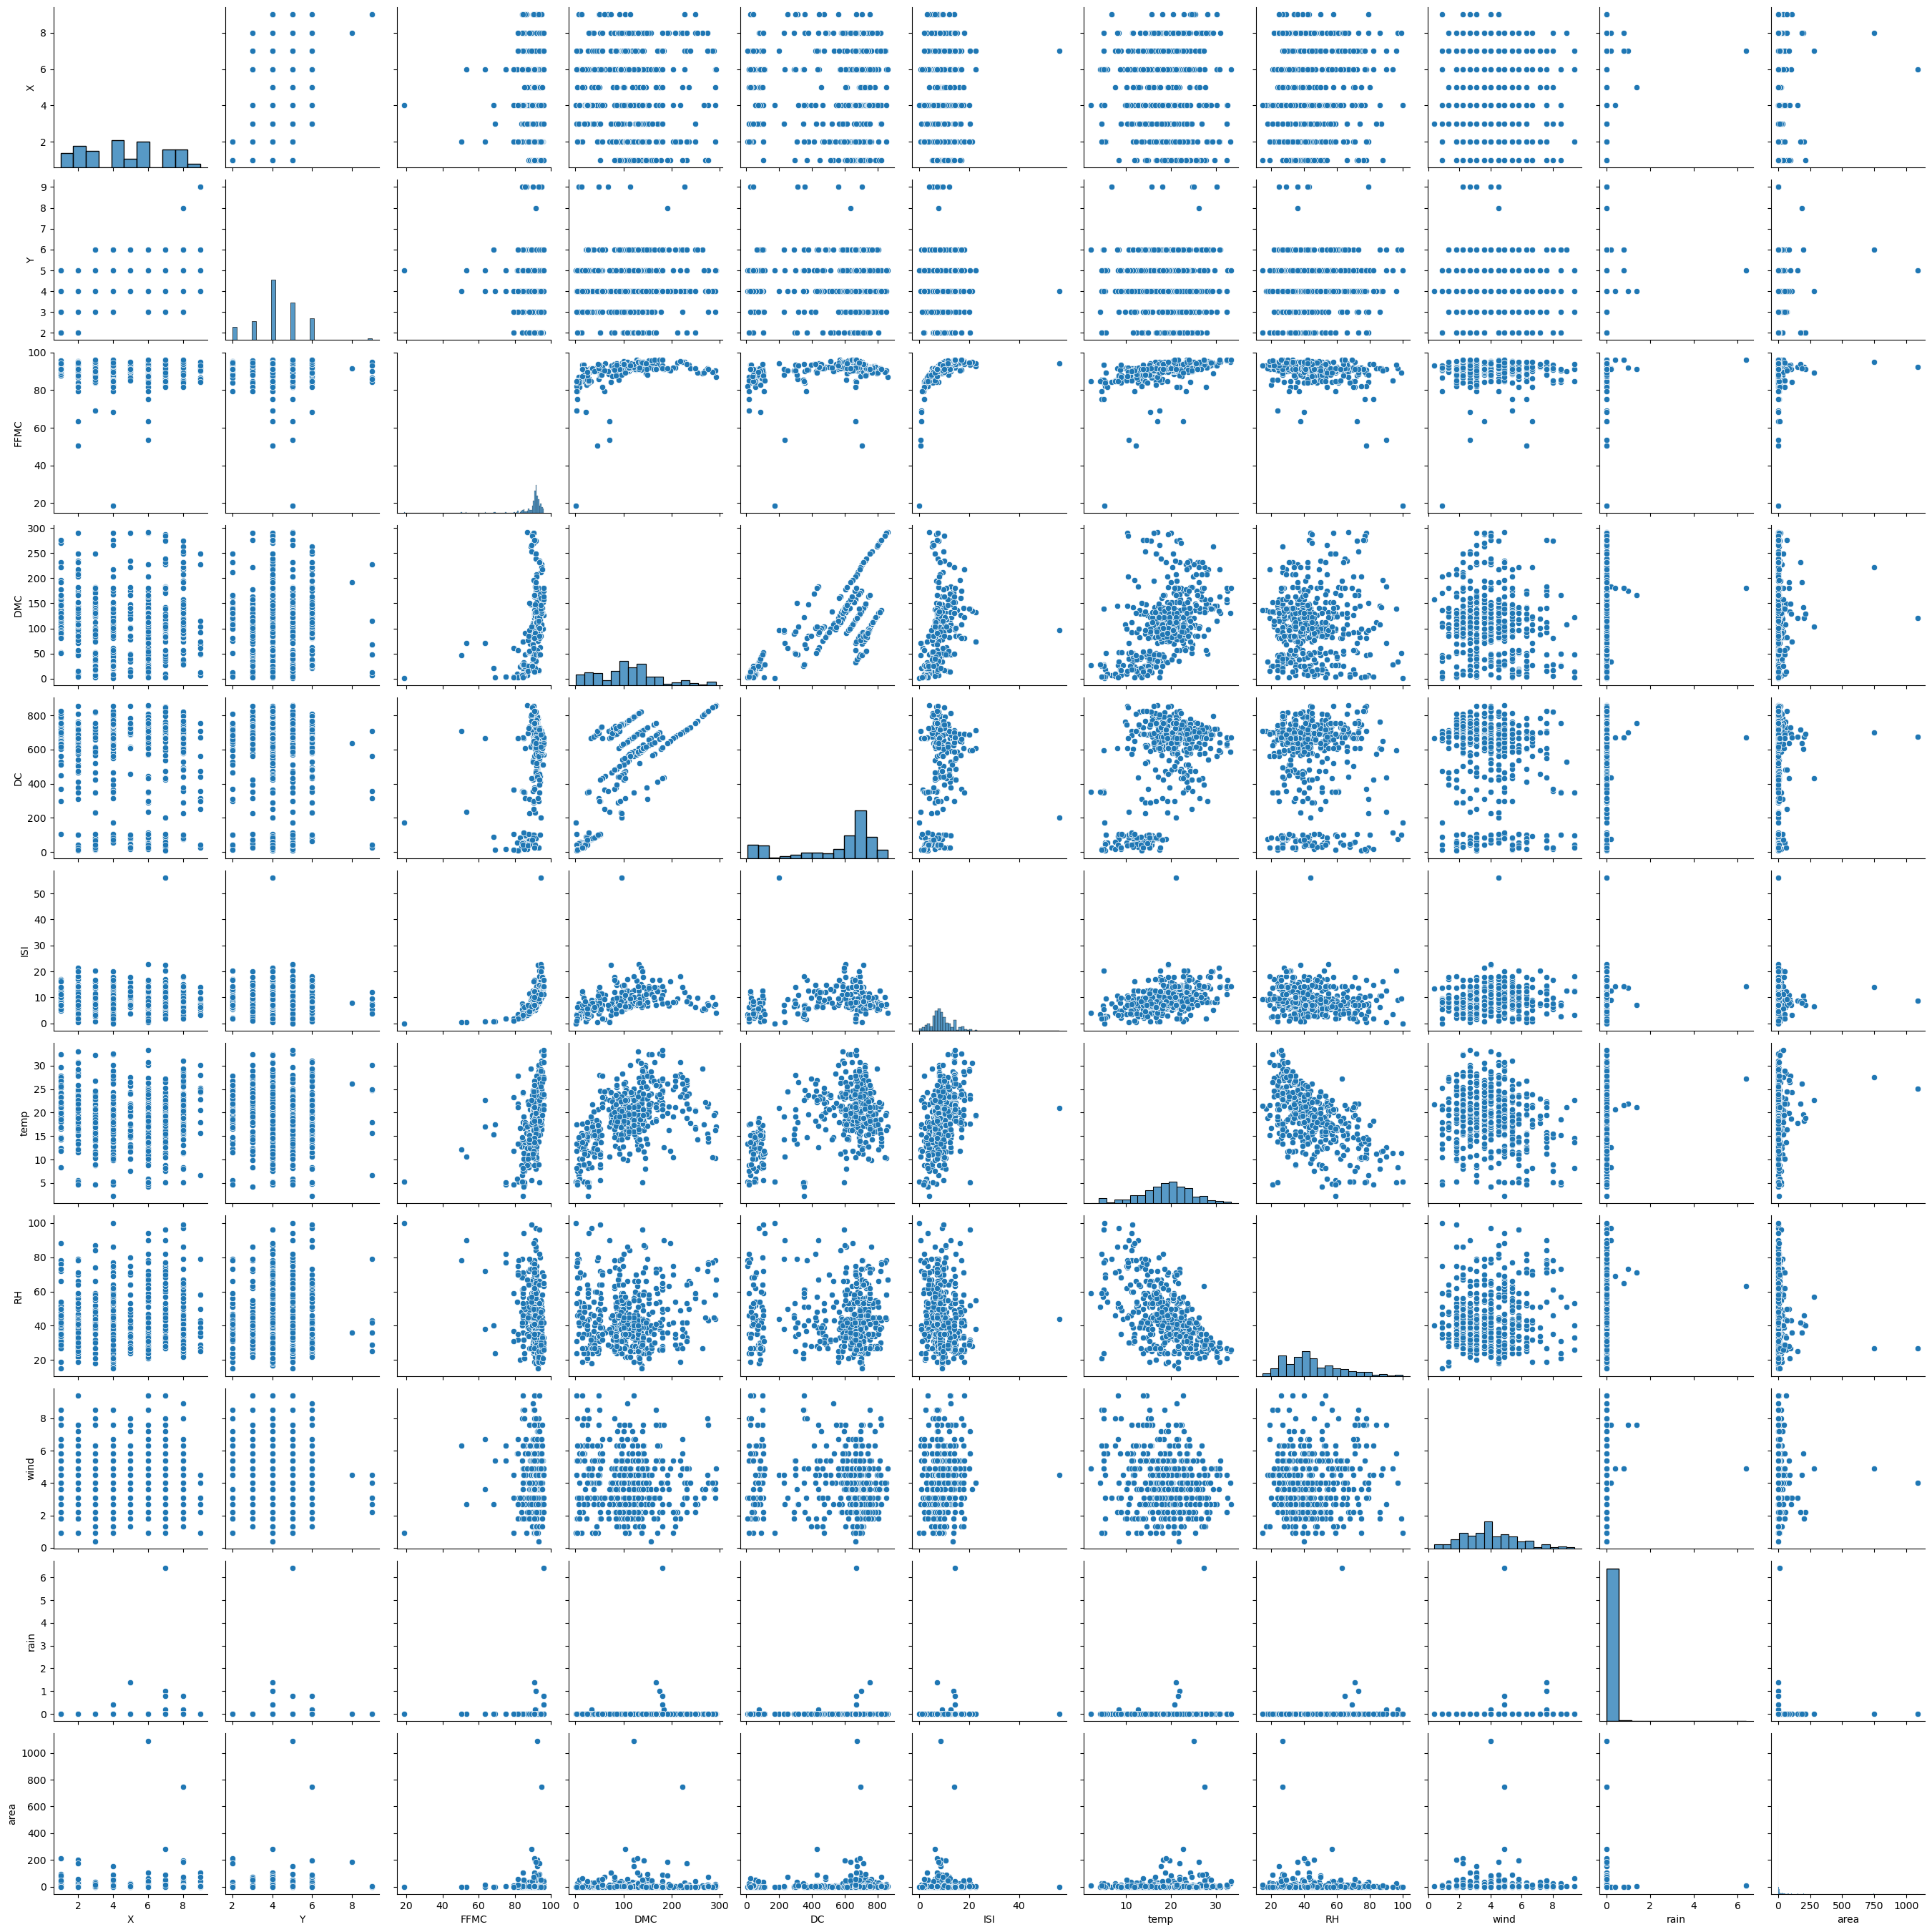

In [17]:
sns.pairplot(df)

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [43]:
import statsmodels.api as sm

# Define predictors and target
y = df["area"]
X = df[["temp", "RH", "wind", "rain"]]

# Fit model
model_1 = sm.OLS(y, sm.add_constant(X)).fit()

# Summary
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.512
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.197
Time:                        16:54:28   Log-Likelihood:                -2877.4
No. Observations:                 517   AIC:                             5765.
Df Residuals:                     512   BIC:                             5786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.4385     20.159     -0.319      0.750     -46.043      33.166
temp           1.0096      0.589      1.713      0.087      -0.148       2.168
RH            -0.1098      0.205     -0.535      0.593      -0.512       0.293
wind           1.2787      1.612      0.793      0.428      -1.889       4.447
rain          -2.8302      9.637     -0.294      0.769     -21.763      16.103
==============================================================================
Omnibus:                      978.182   Durbin-Watson:                   1.641
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           789231.331
Skew:                          12.658   Prob(JB):                         0.00
Kurtosis:                     192.728   Cond. No.                         365.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [91]:
# None linearity
df["temp_sq"] = df["temp"]**2

X = df[["temp","temp_sq","RH","wind","rain"]]

model_2 = sm.OLS(df["log_area"], sm.add_constant(X)).fit()

model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.599
Date:                Sat, 04 Jul 2026   Prob (F-statistic):             0.0246
Time:                        17:39:03   Log-Likelihood:                -899.98
No. Observations:                 517   AIC:                             1812.
Df Residuals:                     511   BIC:                             1837.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7392      0.571      3.048      0.002       0.618       2.860
temp          -0.1132      0.048     -2.377      0.018      -0.207      -0.020
temp_sq        0.0035      0.001      2.747      0.006       0.001       0.006
RH            -0.0020      0.004     -0.448      0.654      -0.011       0.007
wind           0.0544      0.035      1.540      0.124      -0.015       0.124
rain           0.0629      0.211      0.298      0.766      -0.351       0.477
==============================================================================
Omnibus:                       95.306   Durbin-Watson:                   0.947
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              146.691
Skew:                           1.211   Prob(JB):                     1.40e-32
Kurtosis:                       3.972   Cond. No.                     4.19e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.19e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [93]:
# Interaction terms
df_quad = df.copy()

# Create quadratic predictor
df_quad["temp_sq"] = df_quad["temp"] ** 2

df_interaction = df.copy()

df_interaction["temp_wind"] = df_interaction["temp"] * df_interaction["wind"]

df_interaction.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,temp_sq,temp_wind
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0,67.24,54.94
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0,324.00,16.20
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0,213.16,18.98
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0,68.89,33.20
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0,129.96,20.52


In [103]:
# Define predictors and target
y = df_interaction["area"]
X = df_interaction[["temp", "RH", "wind", "rain", "temp_wind"]]

model_3 = sm.OLS(endog=y, exog=sm.add_constant(X))
ols_results = model_3.fit()
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.271
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.275
Time:                        17:55:10   Log-Likelihood:                -2877.2
No. Observations:                 517   AIC:                             5766.
Df Residuals:                     511   BIC:                             5792.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.5668     30.689      0.214      0.831     -53.725      66.858
temp           0.3458      1.320      0.262      0.793      -2.247       2.938
RH            -0.1387      0.211     -0.656      0.512      -0.554       0.277
wind          -1.1997      4.693     -0.256      0.798     -10.421       8.021
rain          -2.9866      9.648     -0.310      0.757     -21.940      15.967
temp_wind      0.1466      0.261      0.562      0.574      -0.366       0.659
==============================================================================
Omnibus:                      977.510   Durbin-Watson:                   1.640
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           786986.075
Skew:                          12.639   Prob(JB):                         0.00
Kurtosis:                     192.458   Cond. No.                     1.03e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [107]:
# Indicator variables
dummy_df = pd.get_dummies(data, columns=["month", "day"], drop_first=True)

y = dummy_df["log_area"]
X = dummy_df.drop(columns=["area", "log_area"]).astype(float)

ols_results = sm.OLS(y, sm.add_constant(X)).fit()

ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.537
Date:                Sat, 04 Jul 2026   Prob (F-statistic):             0.0404
Time:                        17:59:16   Log-Likelihood:                -884.63
No. Observations:                 517   AIC:                             1827.
Df Residuals:                     488   BIC:                             1950.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5372      1.753      0.307      0.759      -2.906       3.981
X              0.0527      0.032      1.632      0.103      -0.011       0.116
Y             -0.0188      0.061     -0.309      0.758      -0.138       0.101
FFMC           0.0088      0.017      0.531      0.595      -0.024       0.042
DMC            0.0041      0.002      2.200      0.028       0.000       0.008
DC            -0.0021      0.001     -1.680      0.094      -0.005       0.000
ISI           -0.0189      0.018     -1.047      0.296      -0.054       0.017
temp          -0.0945      0.072     -1.306      0.192      -0.237       0.048
RH            -0.0017      0.006     -0.269      0.788      -0.014       0.011
wind           0.0602      0.038      1.570      0.117      -0.015       0.136
rain           0.0399      0.214      0.186      0.853      -0.381       0.461
temp_sq        0.0032      0.002      1.896      0.059      -0.000       0.006
month_aug      0.6280      0.837      0.750      0.453      -1.017       2.273
month_dec      1.6894      0.842      2.005      0.045       0.034       3.345
month_feb      0.0539      0.564      0.096      0.924      -1.055       1.163
month_jan     -0.6537      1.230     -0.531      0.595      -3.071       1.763
month_jul      0.3637      0.727      0.500      0.617      -1.064       1.792
month_jun     -0.0199      0.670     -0.030      0.976      -1.336       1.296
month_mar     -0.2797      0.506     -0.552      0.581      -1.275       0.715
month_may      0.8825      1.102      0.801      0.424      -1.283       3.048
month_nov     -1.1167      1.476     -0.757      0.450      -4.016       1.783
month_oct      1.1052      0.991      1.115      0.266      -0.843       3.053
month_sep      1.3105      0.936      1.400      0.162      -0.529       3.150
day_mon        0.0993      0.228      0.436      0.663      -0.348       0.546
day_sat        0.3007      0.217      1.385      0.167      -0.126       0.728
day_sun        0.1957      0.211      0.926      0.355      -0.220       0.611
day_thu        0.0188      0.241      0.078      0.938      -0.455       0.493
day_tue        0.3090      0.235      1.315      0.189      -0.153       0.771
day_wed        0.1627      0.247      0.659      0.510      -0.322       0.648
==============================================================================
Omnibus:                       79.756   Durbin-Watson:                   0.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              113.769
Skew:                           1.090   Prob(JB):                     1.97e-25
Kurtosis:                       3.726   Cond. No.                     2.55e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is co

In [79]:
# log transformation
import numpy as np

# Copy the data
df_log = df.copy()

# Log transform the target
df_log["area"] = np.log1p(df_log["area"])

df_log.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,temp_sq,temp_wind
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0,67.24,54.94
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0,324.00,16.20
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0,213.16,18.98
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0,68.89,33.20
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0,129.96,20.52


In [105]:
# Fit the model

y = df_log["area"]
X = df_log[["temp", "RH", "wind", "rain"]]

model_5 = sm.OLS(y, sm.add_constant(X))
ols_results = model_5.fit()

ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.252
Time:                        17:56:36   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7420      0.443      1.674      0.095      -0.129       1.613
temp           0.0128      0.013      0.985      0.325      -0.013       0.038
RH            -0.0028      0.005     -0.629      0.530      -0.012       0.006
wind           0.0626      0.035      1.766      0.078      -0.007       0.132
rain           0.0852      0.212      0.402      0.688      -0.331       0.501
==============================================================================
Omnibus:                       91.211   Durbin-Watson:                   0.925
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              137.245
Skew:                           1.189   Prob(JB):                     1.58e-30
Kurtosis:                       3.847   Cond. No.                         365.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [138]:
# Create quadratic term
df["temp_sq"] = df["temp"]**2

# Define predictors and target
y = df["log_area"]
X = df[["temp", "temp_sq", "RH", "wind", "rain"]]

# Define model
model_6 = sm.OLS(endog=y, exog=sm.add_constant(X))
ols_results = model_6.fit()
ols_results.summary()

print("Baseline")
print("R2:", round(model_1.rsquared,4))
print("Adj R2:", round(model_1.rsquared_adj,4))
print("AIC:", round(model_1.aic,2))
print("BIC:", round(model_1.bic,2))

print()

model_4 = sm.OLS(y, sm.add_constant(X)).fit()

print("Improved")
print("R²:", round(model_4.rsquared, 4))
print("Adjusted R²:", round(model_4.rsquared_adj, 4))
print("AIC:", round(model_4.aic, 2))
print("BIC:", round(model_4.bic, 2))

Baseline
R2: 0.0117
Adj R2: 0.004
AIC: 5764.82
BIC: 5786.06

Improved
R²: 0.0248
Adjusted R²: 0.0153
AIC: 1811.95
BIC: 1837.44


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


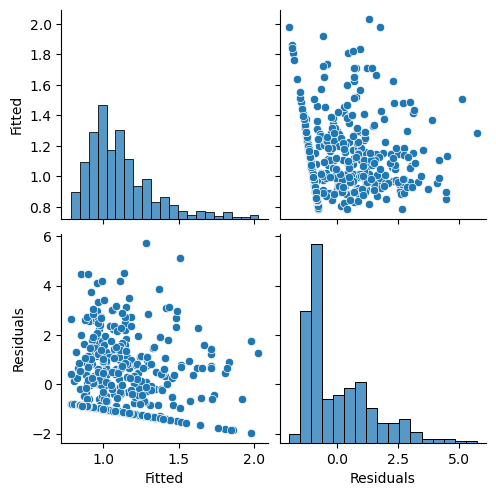

In [136]:
diagnostics = pd.DataFrame({
    "Fitted": ols_results.fittedvalues,
    "Residuals": ols_results.resid
})

# Pairplot
sns.pairplot(diagnostics)
plt.show()

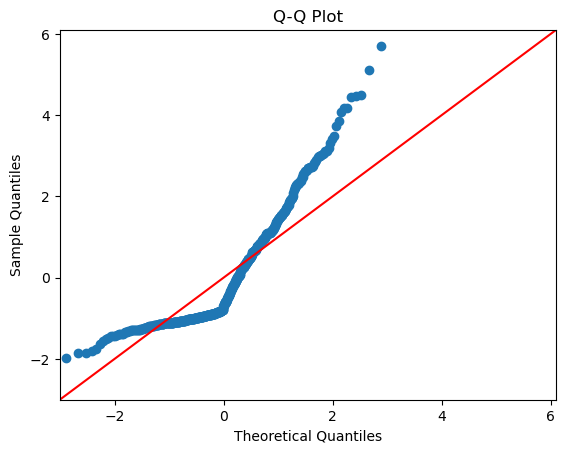

In [140]:
# Q-Q plot
sm.qqplot(ols_results.resid, line="45")
plt.title("Q-Q Plot")
plt.show()

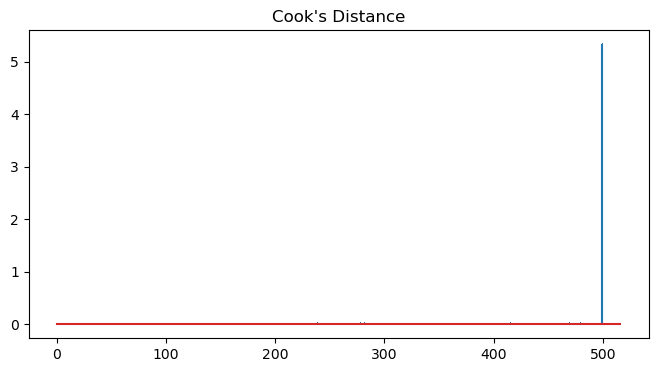

In [142]:
# Cook's Distance
influence = model2.get_influence()
cooks = influence.cooks_distance[0]

plt.figure(figsize=(8,4))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.title("Cook's Distance")
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Define predictors and target
X = pd.get_dummies(df.drop(columns=["area", "log_area"]), drop_first=True)
y = df["log_area"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the predictors
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Ridge Regression
ridge = Ridge(alpha=1).fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.01).fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# Compare models
print("Ridge")
print("MSE:", round(mean_squared_error(y_test, ridge_pred), 4))
print("Coefficients:")
print(ridge.coef_)

print()

print("Lasso")
print("MSE:", round(mean_squared_error(y_test, lasso_pred), 4))
print("Coefficients:")
print(lasso.coef_)

Ridge
MSE: 2.0352
Coefficients:
[ 0.14573629 -0.00144156  0.1144652   0.26465399 -0.42236064 -0.07280973
 -0.17392463  0.11180779  0.16264557  0.00744609  0.39960147 -0.07724742
  0.22300461  0.22443009  0.04334173  0.0429704   0.09255749  0.0013802
  0.00662999  0.15818747 -0.03638494  0.1433351   0.55366525  0.09643333
  0.11056858 -0.01676312  0.02020661  0.09629645  0.00112897]

Lasso
MSE: 2.0017
Coefficients:
[ 0.14098166  0.          0.0533106   0.17152649 -0.09821886 -0.02416632
 -0.          0.08667186  0.07636303  0.0014036   0.15543622 -0.
 -0.0448389   0.19965909  0.03201194  0.         -0.         -0.03773479
  0.          0.14339618 -0.03297182  0.          0.18283908  0.07675803
  0.08327342 -0.01580012  0.00040211  0.0744148  -0.00801011]


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [154]:
# Create binary target
threshold = df["area"].median()
df["HighFire"] = (df["area"] > threshold).astype(int)

# Define predictors and target
X = pd.get_dummies(df.drop(columns=["area", "log_area", "HighFire"]), drop_first=True)
y = df["HighFire"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [166]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Train the model
log_model = LogisticRegression(max_iter=870)
log_model.fit(X_train_scaled, y_train)

# Display intercept and coefficients
print("Intercept:", log_model.intercept_)
print("Coefficients:", log_model.coef_)

# Predict probabilities and classes
y_prob = log_model.predict_proba(X_test_scaled)
y_pred = log_model.predict(X_test_scaled)

# Evaluate the model
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))


Intercept: [0.02787857]
Coefficients: [[ 0.12652579  0.08571864  0.28203574 -0.01137096 -0.01193579 -0.11916194
   0.08457133  0.24501685  0.69842637  0.02447723  0.49112935 -0.52763701
   0.02455886  0.45973977  0.07939545 -0.06969726  0.03205739 -0.00520565
  -0.01870294  0.25783945 -0.19431781 -0.078767    0.27256563  0.17676977
   0.12305906 -0.13901803  0.06555705  0.05091995  0.03890898]]

Accuracy: 0.5128
Precision: 0.5068
Recall: 0.4805
F1-score: 0.4933


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [172]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
X_vif = X.copy()

# Convert boolean columns to integers
X_vif = X_vif.replace({True: 1, False: 0})

# Convert all columns to float
X_vif = X_vif.astype(float)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    round(variance_inflation_factor(X_vif.values, i), 3)
    for i in range(X_vif.shape[1])
]

print(vif)

     Variable      VIF
0           X    7.779
1           Y   19.939
2        FFMC  263.768
3         DMC   14.697
4          DC  154.934
5         ISI    8.722
6        temp  556.412
7          RH   19.170
8        wind   70.574
9        rain    1.091
10    temp_sq  134.820
11  temp_wind   74.626
12  month_aug   67.295
13  month_dec    3.573
14  month_feb    3.056
15  month_jan    1.233
16  month_jul    8.841
17  month_jun    4.012
18  month_mar    7.118
19  month_may    1.279
20  month_nov    1.123
21  month_oct    7.712
22  month_sep   78.673
23    day_mon    1.989
24    day_sat    2.068
25    day_sun    2.210
26    day_thu    1.837
27    day_tue    1.839
28    day_wed    1.720


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

Regression: We can confidently say that the improved regression model performed better than the baseline model.

Classification: Also we can confidently conclude that Logistic regression accurately classified high-risk and low-risk fires.

Trade-off: Regression is better for predicting fire size, while logistic regression is better for risk classification.

Recommendation: I do recommend that we use the improved regression model for prediction and logistic regression for wildfire risk assessment.